In [1]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm


In [83]:
EJ = 3
EJ_over_EL_list = np.linspace(20,30,41)
EJ_over_EC_list = np.linspace(2,10,41)

X, Y = np.meshgrid(EJ_over_EC_list,EJ_over_EL_list)

import pickle
with open('data_v3.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)


hbar = 1/(2*np.pi)
def one_over_f_loss_rate(omega, EL, phi_element, one_over_f_flux_noise_amplitude):
    return_val = 8 * np.pi**3  # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val *= (phi_element)**2 / omega  # GHz
    return return_val

def dielectric_loss_rate(omega, EC, phi_element, Q_cap):
    temp_in_mK = 42  # K
    kB = 8.617333262e-5  # eV K−1
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    return_val = hbar * omega**2  # h*GHZ^2
    return_val /= (4 * EC * Q_cap)  # GHZ
    return_val *= phi_element**2  # GHZ

    hbar_in_eVs = 6.5821e-16  # eV s
    coth_arg = beta * hbar_in_eVs * omega / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val *= 1 / np.tanh(coth_arg)  # GHZ
    return return_val

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0
    return_val = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    return_val *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return_val = return_val**(-1/2)  # ns
    return return_val  # Seems the unit here should be millisecond? Where did miss a 1e3?

def compute_lifetimes(one_over_f_flux_noise_amplitude, Q_cap):
    conventional_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down01_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    for i in range(len(EJ_over_EL_list)):
        for j in range(len(EJ_over_EC_list)):
            EC = EJ / EJ_over_EC_list[j]
            EL = EJ / EJ_over_EL_list[i]

            # Conventional lifetimes
            omega_conventional = conventional_freq_array[i, j] * 2 * np.pi
            phi_conventional = conventional_phi_element_array[i, j]
            second_order_conventional = conventional_2nd_order_array[i, j]

            conventional_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_conventional, EC, phi_conventional, Q_cap)
            conventional_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_conventional, EL, phi_conventional, one_over_f_flux_noise_amplitude)
            conventional_dephasing_lifetime[i, j] = T_phi(second_order_conventional, one_over_f_flux_noise_amplitude)

            # Upside down 01 lifetimes
            omega_upside_down01 = upside_down_freq01_array[i, j] * 2 * np.pi
            phi_upside_down01 = upside_down_phi_element01_array[i, j]
            second_order_upside_down01 = upside_down_2nd_order_01_array[i, j]

            upside_down01_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_upside_down01, EC, phi_upside_down01, Q_cap)
            upside_down01_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_upside_down01, EL, phi_upside_down01, one_over_f_flux_noise_amplitude)
            upside_down01_dephasing_lifetime[i, j] = T_phi(second_order_upside_down01, one_over_f_flux_noise_amplitude)

            # Upside down 12 lifetimes
            omega_upside_down12 = upside_down_freq12_array[i, j] * 2 * np.pi
            phi_upside_down12 = upside_down_phi_element12_array[i, j]
            second_order_upside_down12 = upside_down_2nd_order_12_array[i, j]

            upside_down12_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_upside_down12, EC, phi_upside_down12, Q_cap)
            upside_down12_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_upside_down12, EL, phi_upside_down12, one_over_f_flux_noise_amplitude)
            upside_down12_dephasing_lifetime[i, j] = T_phi(second_order_upside_down12, one_over_f_flux_noise_amplitude)

    return {
        "conventional_dielectric_lifetime": conventional_dielectric_lifetime,
        "conventional_one_over_f_loss_lifetime": conventional_one_over_f_loss_lifetime,
        "conventional_dephasing_lifetime": conventional_dephasing_lifetime,
        "upside_down01_dielectric_lifetime": upside_down01_dielectric_lifetime,
        "upside_down01_one_over_f_loss_lifetime": upside_down01_one_over_f_loss_lifetime,
        "upside_down01_dephasing_lifetime": upside_down01_dephasing_lifetime,
        "upside_down12_dielectric_lifetime": upside_down12_dielectric_lifetime,
        "upside_down12_one_over_f_loss_lifetime": upside_down12_one_over_f_loss_lifetime,
        "upside_down12_dephasing_lifetime": upside_down12_dephasing_lifetime
    }

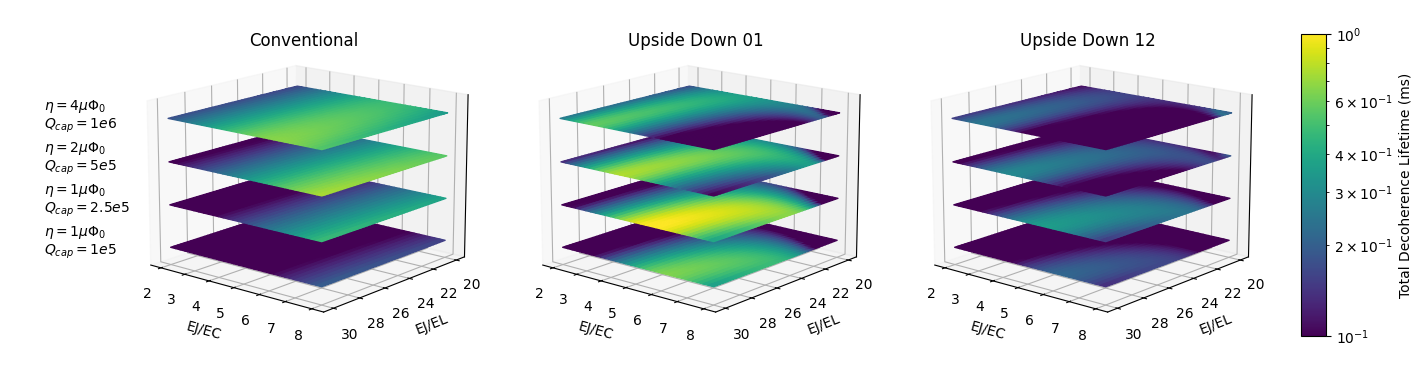

In [92]:
combinations = [[4e-6, 1e6],  # more 1/f, less dielectric loss 
                [2e-6, 5e5], 
                [1e-6, 2.5e5],
                [1e-6, 1e5]]

results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}


for amplitude, Q in combinations:
    lifetimes = compute_lifetimes(amplitude, Q)
    for catagory in ["conventional", "upside_down01", "upside_down12"]:
        dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
        T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
        results[catagory].append(1/(2/T1_tot + 1/dephasing_T))
        # results[catagory].append(dephasing_T)

# global_min = float('inf')
# global_max = float('-inf')
# for key in results:
#     for array in results[key]:
#         global_min = min(global_min,array.min())
#         global_max = max(global_max, array.max())
norm = LogNorm(1e-1, 1)
# norm = LogNorm(global_min, global_max)

fig = plt.figure(figsize=(14, 3.5))
cmap = plt.get_cmap('viridis')

categories = ["conventional", "upside_down01", "upside_down12"]
titles = ["Conventional", "Upside Down 01", "Upside Down 12"]
z_slices = [6, 3, 0, -3]
positions = [
    [0.08, 0.0, 0.26, 1],
    [0.36, 0.0, 0.26, 1],
    [0.64, 0.0, 0.26, 1],
    [0.92, 0.0, 0.02, 1]
]


X, Y = np.meshgrid(EJ_over_EC_list[:31],EJ_over_EL_list)

for idx, category in enumerate(categories):
    ax = fig.add_axes(positions[idx], projection='3d')
    ax.set_title(titles[idx],y=0.95)
    for i, z_slice in enumerate(z_slices):
        data = results[category][i][:,:31]
        norm_data = norm(data)
        # c = ax.plot_surface(X, Y, data, levels=1000, zdir='z', offset=z_slice, cmap=cmap, norm=norm)
        z = np.full_like(X, z_slice)
        c = ax.plot_surface(X, Y, z, rstride=1, cstride=1, facecolors=plt.colormaps.get_cmap(cmap)(norm_data), shade=False)
    
    ax.set_xlabel('EJ/EC')
    ax.set_ylabel('EJ/EL')

    ax.set_zticks([])
    ax.set_zlim(min(z_slices) - 1, max(z_slices) + 1)
    ax.view_init(elev=15, azim=310)
    ax.invert_yaxis()
    # ax.set_xlim(3,6)


cbar_ax = fig.add_axes(positions[3])
cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax=cbar_ax, shrink=2,orientation='vertical', label='Total Decoherence Lifetime (ms)', pad=0.9, aspect=12,location='right',fraction=0.9,anchor=(-0.4,0.5))
cbar_ax.axis('off')

z_label_ax = fig.add_axes([0.0, 0.0, 0.08, 1])
z_label_ax.text(0.3,0.66,rf'''$\eta = 4\mu\Phi_0$
$Q_{{cap}}=1e6$''')
z_label_ax.text(0.3,0.54,rf'''$\eta = 2\mu\Phi_0$
$Q_{{cap}}=5e5$''')
z_label_ax.text(0.3,0.42,rf'''$\eta = 1\mu\Phi_0$
$Q_{{cap}}=2.5e5$''')
z_label_ax.text(0.3,0.3,rf'''$\eta = 1\mu\Phi_0$
$Q_{{cap}}=1e5$''')
z_label_ax.axis('off')

# plt.tight_layout()
plt.savefig('test.pdf')
plt.show()